# TensorMesh GPU Demo — J2 (von Mises) Plasticity, Tension-Unload Cycle

3D rate-independent **J2 plasticity** with linear isotropic hardening, on a steel cube under prescribed end displacement, going through a full **load → unload → reverse-yield** cycle.

What this demo shows:

1. **Built-in `J2Plasticity` assembler** — closed-form return-mapping at the quadrature point, expressed as an *algorithmic incremental potential*, so the residual / consistent tangent are obtained by autograd.
2. **Per-quadrature history variables** — `eps_p` (plastic strain tensor) and `α` (cumulative equivalent plastic strain) are persistent buffers on the assembler, updated via `model.update_state(u)` after each Newton/LBFGS convergence.
3. **Cyclic load history** — tension to 20% strain, unload back through zero, reverse to a small compression. The classic linear-hardening response (Bauschinger-free since hardening is isotropic) is reproduced.
4. **Reaction-force diagnostic via autograd** — the reaction on the prescribed face is obtained as `dE/du` at the constrained DOFs, without ever forming a stiffness matrix.

**Problem**: a 0.5 m steel cube (`E = 200 GPa`, `ν = 0.3`, `σ_y = 250 MPa`, `H = 1 GPa`); roller-clamped on the left face, displacement-controlled on the right face.

## 1. Setup

In [1]:
import time, warnings
warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt

from tensormesh import Mesh
from tensormesh.dataset.mesh import gen_cube
from tensormesh.assemble import J2Plasticity
from tensormesh.material import IsotropicMaterial

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 2. Mesh + material

In [2]:
L = 0.5
mesh = gen_cube(chara_length=0.07, left=0, right=L, bottom=0, top=L, front=0, back=L).double().to(device)
print(f'Mesh: {mesh.n_points} nodes, {mesh.n_elements} elements')

mat = IsotropicMaterial('SteelHard', E=200e9, nu=0.3, rho=7850, sigma_y=250e6, H=1e9)
print(f'Material: {mat.name}, E={mat.E:.1e} Pa, ν={mat.nu}, σ_y={mat.sigma_y:.1e} Pa, H={mat.H:.1e} Pa')

model = J2Plasticity.from_mesh(mesh, material=mat).to(device)
print('History variables (per element type):')
for et, h in model.history.items():
    print(f'  {et}: eps_p shape {tuple(h["eps_p"].shape)}, alpha shape {tuple(h["alpha"].shape)}')


Mesh: 692 nodes, 2586 elements
Material: SteelHard, E=2.0e+11 Pa, ν=0.3, σ_y=2.5e+08 Pa, H=1.0e+09 Pa


History variables (per element type):
  tetra: eps_p shape (2586, 4, 3, 3), alpha shape (2586, 4)


## 3. Boundary conditions

Roller-clamped on the **left face** (x-component fixed), single corner pinned in y, single edge pinned in z (to remove rigid-body motion). The **right face** has its x-component prescribed by the load schedule.

In [3]:
pts = mesh.points
eps_t = 1e-5
face_L = pts[:, 0] < eps_t
face_R = pts[:, 0] > L - eps_t
p0 = (pts[:, 0] < eps_t) & (pts[:, 1] < eps_t) & (pts[:, 2] < eps_t)
p1 = (pts[:, 0] < eps_t) & (pts[:, 1] > L - eps_t) & (pts[:, 2] < eps_t)
print(f'Left  face: {int(face_L.sum())} nodes')
print(f'Right face: {int(face_R.sum())} nodes')

Left  face: 99 nodes
Right face: 99 nodes


## 4. Load schedule

Tension to 20% strain over 30 steps, then unload to -4% strain over 30 more steps.

Total steps: 60  (load 30 + unload 30)


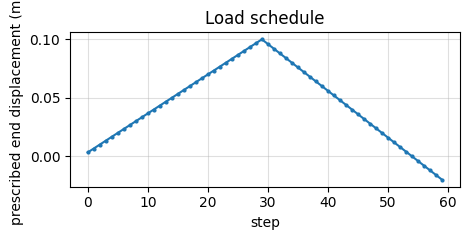

In [4]:
u_peak = 0.10            # 20% strain on 0.5m bar
n_load = 30
n_unload = 30
schedule = np.concatenate([
    np.linspace(0, u_peak, n_load + 1)[1:],
    np.linspace(u_peak, -0.02, n_unload + 1)[1:],
])
print(f'Total steps: {len(schedule)}  (load {n_load} + unload {n_unload})')

plt.figure(figsize=(5, 2.5))
plt.plot(schedule, '-o', ms=2)
plt.xlabel('step'); plt.ylabel('prescribed end displacement (m)')
plt.title('Load schedule'); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## 5. Solve the cycle

For each load step we minimize the algorithmic incremental potential using LBFGS + strong-Wolfe, then commit the converged plastic state via `model.update_state(u)`.

In [5]:
u = torch.zeros_like(pts, requires_grad=True)
disps, forces, max_alpha_hist = [], [], []

t0 = time.time()
for i, target_disp in enumerate(schedule):
    opt = torch.optim.LBFGS([u], lr=1.0, max_iter=80, history_size=100, line_search_fn='strong_wolfe')
    mask_t = torch.ones_like(u); val_t = torch.zeros_like(u)
    mask_t[face_L, 0] = 0
    mask_t[p0, 1] = 0; mask_t[p0, 2] = 0
    mask_t[p1, 2] = 0
    mask_t[face_R, 0] = 0
    val_t[face_R, 0] = target_disp

    def closure():
        opt.zero_grad()
        u_act = u * mask_t + val_t
        edata = {
            'eps_p_n': {et: h['eps_p'] for et, h in model.history.items()},
            'alpha_n': {et: h['alpha'] for et, h in model.history.items()},
        }
        E = model.energy(point_data={'displacement': u_act}, element_data=edata)
        if E.requires_grad:
            E.backward()
        return E

    opt.step(closure)

    # Reaction force: differentiate energy w.r.t. the constrained displacement.
    u_clone = (u * mask_t + val_t).detach().clone().requires_grad_(True)
    edata = {
        'eps_p_n': {et: h['eps_p'] for et, h in model.history.items()},
        'alpha_n': {et: h['alpha'] for et, h in model.history.items()},
    }
    Ef = model.energy(point_data={'displacement': u_clone}, element_data=edata)
    Ef.backward()
    Fx = u_clone.grad[face_R, 0].sum().item()

    with torch.no_grad():
        u.data.copy_(u * mask_t + val_t)
        model.update_state(u.data)
        max_alpha = next(iter(model.history.values()))['alpha'].max().item()

    disps.append(target_disp); forces.append(Fx); max_alpha_hist.append(max_alpha)

    if i % 6 == 0 or i == len(schedule) - 1:
        phase = 'load  ' if i < n_load else 'unload'
        print(f'step {i:3d} [{phase}]  d = {target_disp:+.4f} m,  F = {Fx:+.3e} N,  max α = {max_alpha:.4f}')

if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'\nTotal solve time: {time.time()-t0:.1f} s')

step   0 [load  ]  d = +0.0033 m,  F = +6.439e+07 N,  max α = 0.0083


step   6 [load  ]  d = +0.0233 m,  F = +7.461e+07 N,  max α = 0.0566


step  12 [load  ]  d = +0.0433 m,  F = +8.474e+07 N,  max α = 0.1015


step  18 [load  ]  d = +0.0633 m,  F = +9.474e+07 N,  max α = 0.1489


step  24 [load  ]  d = +0.0833 m,  F = +1.048e+08 N,  max α = 0.1953


...

step  36 [unload]  d = +0.0720 m,  F = -1.254e+08 N,  max α = 0.3015


step  42 [unload]  d = +0.0480 m,  F = -1.377e+08 N,  max α = 0.3661


step  48 [unload]  d = +0.0240 m,  F = -1.499e+08 N,  max α = 0.4274


step  54 [unload]  d = +0.0000 m,  F = -1.620e+08 N,  max α = 0.4862


step  59 [unload]  d = -0.0200 m,  F = -1.720e+08 N,  max α = 0.5341

Total solve time: 39.1 s


## 6. Force-displacement and plastic-strain evolution

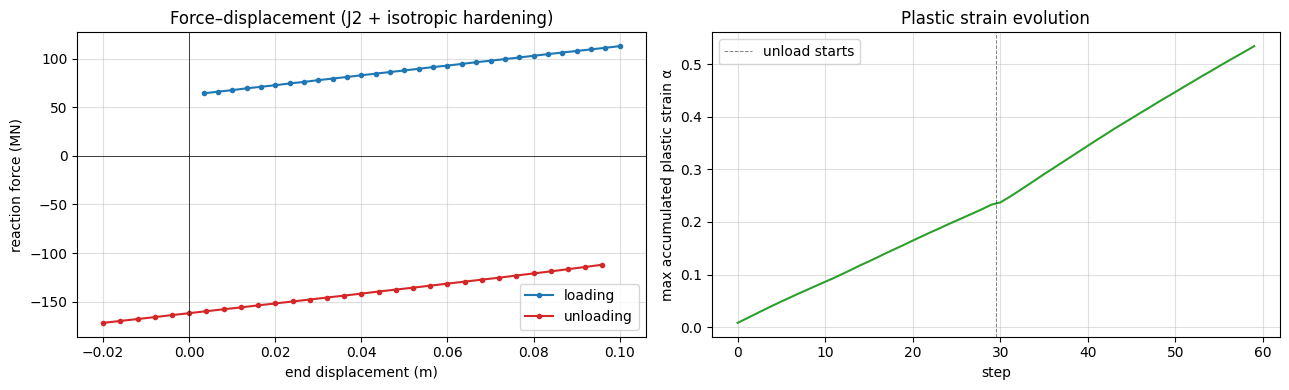

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(disps[:n_load],  np.array(forces[:n_load]) / 1e6, '-o', ms=3, color='C0', label='loading')
ax.plot(disps[n_load:],  np.array(forces[n_load:]) / 1e6, '-o', ms=3, color='C3', label='unloading')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('end displacement (m)'); ax.set_ylabel('reaction force (MN)')
ax.set_title('Force–displacement (J2 + isotropic hardening)')
ax.legend(); ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(max_alpha_hist, '-', color='C2')
ax.axvline(n_load - 0.5, color='k', ls='--', lw=0.7, alpha=0.5, label='unload starts')
ax.set_xlabel('step'); ax.set_ylabel('max accumulated plastic strain α')
ax.set_title('Plastic strain evolution')
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('plast_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Plastic strain distribution in the bar

α is per-element-per-quadrature; we average over quadrature points and plot the centroid scatter. For a uniaxial bar the field is nearly uniform — the small variation comes from the irregular tet mesh.

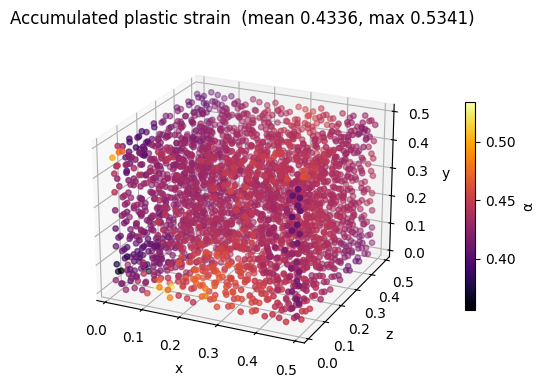

In [7]:
et = next(iter(model.history.keys()))
alpha_elem = model.history[et]['alpha'].mean(dim=1).cpu().numpy()
elements_np = mesh.cells[et].cpu().numpy()
pts_np = pts.cpu().numpy()
centroids = pts_np[elements_np].mean(axis=1)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(centroids[:, 0], centroids[:, 2], centroids[:, 1], c=alpha_elem, cmap='inferno', s=15)
plt.colorbar(sc, ax=ax, shrink=0.6, label='α')
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
ax.set_title(f'Accumulated plastic strain  (mean {alpha_elem.mean():.4f}, max {alpha_elem.max():.4f})')
ax.view_init(elev=22, azim=-65)
plt.tight_layout()
plt.savefig('plast_alpha_field.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Summary

* Used the built-in `J2Plasticity` assembler — no manual return-mapping code.
* Drove a 60-step displacement-controlled cycle on a 3D steel cube.
* Recovered the classic linear-hardening tension curve, elastic unloading, and reverse plasticity, all with autograd handling the consistent tangent implicitly.
* Plastic strain history persisted across steps through `model.update_state(...)`.

Swap `J2Plasticity` for a custom `ElementAssembler` with your own incremental potential to plug in any other return-mapping model (Drucker-Prager, anisotropic plasticity, viscoplastic regularization …).